# Arch-PoC Comparison: 03f (MTL) vs 03g (ST)
**Questions:**
1. Best model configuration: (a) ST accuracy · (b) MTL accuracy · (c) MTL RMSE  
2. Does multi-task learning (MTL) improve classification accuracy vs single-task (ST)?

Task IDs: 0–2, 9–12 (both MTL + ST) · 14 (ST only) · n_splits=1 throughout

In [10]:
# ── Cell 1: Imports & config ──────────────────────────────────────────────
import sys, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import accuracy_score
from scipy import stats

sys.path.insert(0, str(Path('..')))
sys.path.insert(0, str(Path('../utils')))
sys.path.insert(0, str(Path('../utils/model_training')))

from pipeline_utils import get_exp_paths
from model_utils_mtl import REG_SENTINEL

EXP_FOLDER = '/vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper'
TASK_IDS   = [0, 1, 2, 9, 10, 11, 12, 14]

MTL_KEYS = [
    'cgd_arch_poc',  'cgd_arch_poc_sc1',  'cgd_arch_poc_sc2',  'cgd_arch_poc_sc3',
    'cgs_arch_poc',  'cgs_arch_poc_sc1',  'cgs_arch_poc_sc2',  'cgs_arch_poc_sc3',
    'ccgd_arch_poc', 'ccgd_arch_poc_sc1', 'ccgd_arch_poc_sc2', 'ccgd_arch_poc_sc3',
]
ST_KEYS = [
    'cgd_arch_poc_st',  'cgd_arch_poc_st_sc1',  'cgd_arch_poc_st_sc2',  'cgd_arch_poc_st_sc3',
    'cgs_arch_poc_st',  'cgs_arch_poc_st_sc1',  'cgs_arch_poc_st_sc2',  'cgs_arch_poc_st_sc3',
    'ccgd_arch_poc_st', 'ccgd_arch_poc_st_sc1', 'ccgd_arch_poc_st_sc2', 'ccgd_arch_poc_st_sc3',
]

ARCH_COLORS = {'CGD': '#1565C0', 'CGS': '#E65100', 'CCGD': '#2E7D32'}

def key_label(k):
    k2 = k.replace('_arch_poc_st', '').replace('_arch_poc', '')
    if '_sc' in k2:
        arch = k2.split('_sc')[0].upper()
        sc   = k2.split('_sc')[-1]
    else:
        arch, sc = k2.upper(), '0'
    return f'{arch} SC{sc}'

print('REG_SENTINEL:', REG_SENTINEL)

REG_SENTINEL: -1.0


In [11]:
# ── Cell 2: Load all result files & build long-form DataFrame ─────────────
exp_paths = get_exp_paths(EXP_FOLDER)

def load_entry(path, fname):
    f = path / 'arch_poc' / fname
    if not f.exists():
        return None
    r = joblib.load(f)
    for ds in r.values():
        for mode in ds.values():
            for entry in mode.values():
                if isinstance(entry, dict) and 'y_trues_' in entry:
                    return entry
    return None

def fold_acc(entry, key):
    pk = f'y_preds_AC_{key}_'
    if entry is None or pk not in entry:
        return np.nan
    return np.mean([accuracy_score(yt, yp)
                    for yt, yp in zip(entry['y_trues_'], entry[pk])])

def fold_rmse(entry, key):
    rp_k, rt_k = f'y_reg_preds_{key}_', f'y_reg_trues_{key}_'
    if entry is None or rp_k not in entry or rt_k not in entry:
        return np.nan
    rmses = []
    for rt, rp in zip(entry[rt_k], entry[rp_k]):
        rt, rp = np.asarray(rt, float), np.asarray(rp, float)
        v = (rt != REG_SENTINEL) & np.isfinite(rt) & np.isfinite(rp)
        if v.sum() >= 2:
            rmses.append(np.sqrt(np.mean((rt[v] - rp[v]) ** 2)))
    return np.mean(rmses) if rmses else np.nan

records = []
for tid in TASK_IDS:
    p   = exp_paths[tid]
    ds  = p.name
    mtl = load_entry(p, 'arch_poc_results.joblib')
    st  = load_entry(p, 'arch_poc_st_results.joblib')
    for k in MTL_KEYS:
        records.append({'task': tid, 'dataset': ds, 'model': k, 'type': 'MTL',
                        'acc': fold_acc(mtl, k), 'rmse': fold_rmse(mtl, k)})
    for k in ST_KEYS:
        records.append({'task': tid, 'dataset': ds, 'model': k, 'type': 'ST',
                        'acc': fold_acc(st, k), 'rmse': np.nan})

df = pd.DataFrame(records)
df['arch'] = df['model'].apply(
    lambda k: 'CGD' if k.startswith('cgd') else ('CGS' if k.startswith('cgs') else 'CCGD'))
df['sc'] = df['model'].apply(
    lambda k: int(k.split('_sc')[-1]) if '_sc' in k else 0)
df['label'] = df['model'].apply(key_label)

DS_ORDER = [exp_paths[t].name for t in TASK_IDS]
df['dataset'] = pd.Categorical(df['dataset'], categories=DS_ORDER, ordered=True)

print(f'Loaded {len(df)} rows  |  {df.dataset.nunique()} datasets')
overview = df.groupby(['type', 'dataset'], observed=True)['acc'].max().unstack('type') * 100
overview.columns.name = 'best acc (%)'
print(overview.round(2))

Loaded 192 rows  |  8 datasets
best acc (%)            MTL     ST
dataset                           
01_ACA_qdPCR          99.63  99.57
02_AMCA_qdLAMP        97.53  97.58
03_AMCA_qdPCR         93.68  94.15
07_ACA_qdPCR_conc...  99.74  99.67
08_AMCA_qdPCR_con...  93.85  95.30
09_Area_Conc          92.29  92.38
10_Range_Conc         90.82  91.26
12_ACA_qdPCR_mult...    NaN  78.52


## 1a — Best ST Model Configuration (accuracy)

/tmp/ipykernel_183829/1462668222.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  st_df.pivot_table(index='label', columns='dataset', values='acc', aggfunc='first') * 100


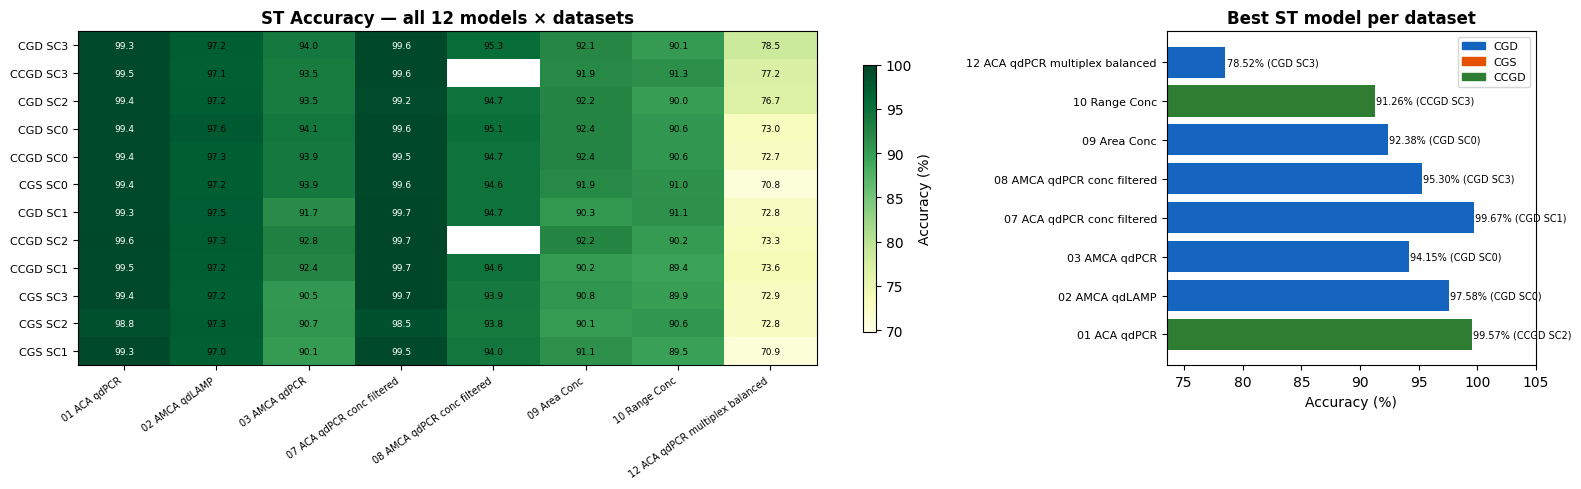


Best ST configuration per dataset:
                        dataset    label arch  sc  acc_pct
                   01_ACA_qdPCR CCGD SC2 CCGD   2   99.567
                 02_AMCA_qdLAMP  CGD SC0  CGD   0   97.582
                  03_AMCA_qdPCR  CGD SC0  CGD   0   94.146
     07_ACA_qdPCR_conc_filtered  CGD SC1  CGD   1   99.670
    08_AMCA_qdPCR_conc_filtered  CGD SC3  CGD   3   95.297
                   09_Area_Conc  CGD SC0  CGD   0   92.381
                  10_Range_Conc CCGD SC3 CCGD   3   91.255
12_ACA_qdPCR_multiplex_balanced  CGD SC3  CGD   3   78.516


In [12]:
st_df = df[df['type'] == 'ST'].copy()

pivot_st = (
    st_df.pivot_table(index='label', columns='dataset', values='acc', aggfunc='first') * 100
).reindex(columns=DS_ORDER)
pivot_st = pivot_st.loc[pivot_st.mean(axis=1).sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2.5, 1]})

ax = axes[0]
im = ax.imshow(pivot_st.values, aspect='auto', cmap='YlGn',
               vmin=pivot_st.min().min()-1, vmax=100)
ax.set_xticks(range(len(pivot_st.columns)))
ax.set_xticklabels([c.replace('_', ' ') for c in pivot_st.columns],
                   rotation=35, ha='right', fontsize=7)
ax.set_yticks(range(len(pivot_st.index)))
ax.set_yticklabels(pivot_st.index, fontsize=8)
for i in range(pivot_st.shape[0]):
    for j in range(pivot_st.shape[1]):
        v = pivot_st.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=6.5,
                    color='black' if v < 98 else 'white')
plt.colorbar(im, ax=ax, shrink=0.8, label='Accuracy (%)')
ax.set_title('ST Accuracy — all 12 models × datasets', fontweight='bold')

ax2 = axes[1]
# .dropna() on idxmax() guards against all-NaN groups
best_st = st_df.loc[st_df.groupby('dataset', observed=True)['acc'].idxmax().dropna()].copy()
best_st = best_st.set_index('dataset').reindex(DS_ORDER).dropna(subset=['acc']).reset_index()
colors  = [ARCH_COLORS[r] for r in best_st['arch']]
ax2.barh(range(len(best_st)), best_st['acc'] * 100, color=colors)
ax2.set_yticks(range(len(best_st)))
ax2.set_yticklabels([d.replace('_', ' ') for d in best_st['dataset']], fontsize=8)
for i, row in best_st.iterrows():
    ax2.text(row['acc']*100 + 0.1, i,
             f"{row['acc']*100:.2f}% ({row['label']})", va='center', fontsize=7)
ax2.set_xlim(left=best_st['acc'].min()*100 - 5, right=105)
ax2.set_xlabel('Accuracy (%)')
ax2.set_title('Best ST model per dataset', fontweight='bold')
ax2.legend(handles=[mpatches.Patch(color=c, label=a) for a, c in ARCH_COLORS.items()],
           fontsize=8)
plt.tight_layout(); plt.show()

print('\nBest ST configuration per dataset:')
print(best_st[['dataset','label','arch','sc','acc']]
      .assign(acc_pct=lambda x: (x.acc*100).round(3))
      .drop(columns='acc').to_string(index=False))

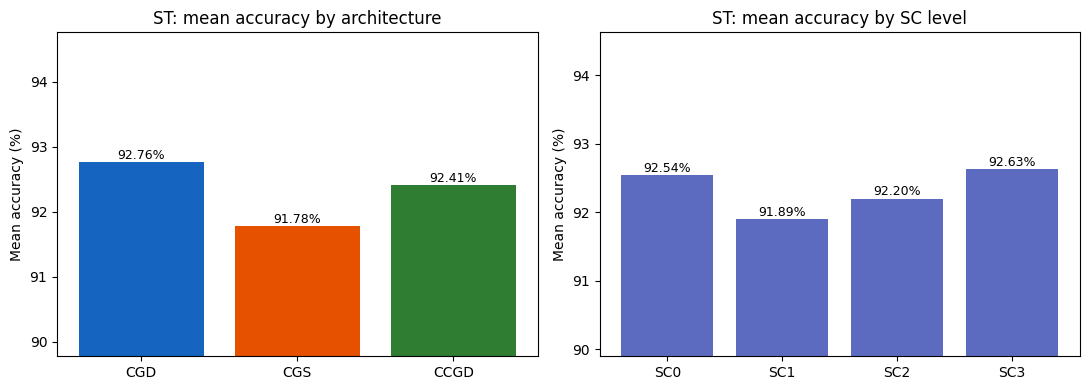

In [13]:
# Architecture & SC-level mean accuracy — ST
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

arch_mean = st_df.groupby('arch')['acc'].mean().reindex(['CGD','CGS','CCGD']) * 100
axes[0].bar(arch_mean.index, arch_mean.values,
            color=[ARCH_COLORS[a] for a in arch_mean.index])
for i, v in enumerate(arch_mean.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)
axes[0].set_ylim(arch_mean.min()-2, arch_mean.max()+2)
axes[0].set_title('ST: mean accuracy by architecture')
axes[0].set_ylabel('Mean accuracy (%)')

sc_mean = st_df.groupby('sc')['acc'].mean() * 100
axes[1].bar([f'SC{s}' for s in sc_mean.index], sc_mean.values, color='#5C6BC0')
for i, v in enumerate(sc_mean.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)
axes[1].set_ylim(sc_mean.min()-2, sc_mean.max()+2)
axes[1].set_title('ST: mean accuracy by SC level')
axes[1].set_ylabel('Mean accuracy (%)')

plt.tight_layout(); plt.show()

## 1b — Best MTL Model Configuration (accuracy)

/tmp/ipykernel_183829/2114833315.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mtl_df.pivot_table(index='label', columns='dataset', values='acc', aggfunc='first') * 100


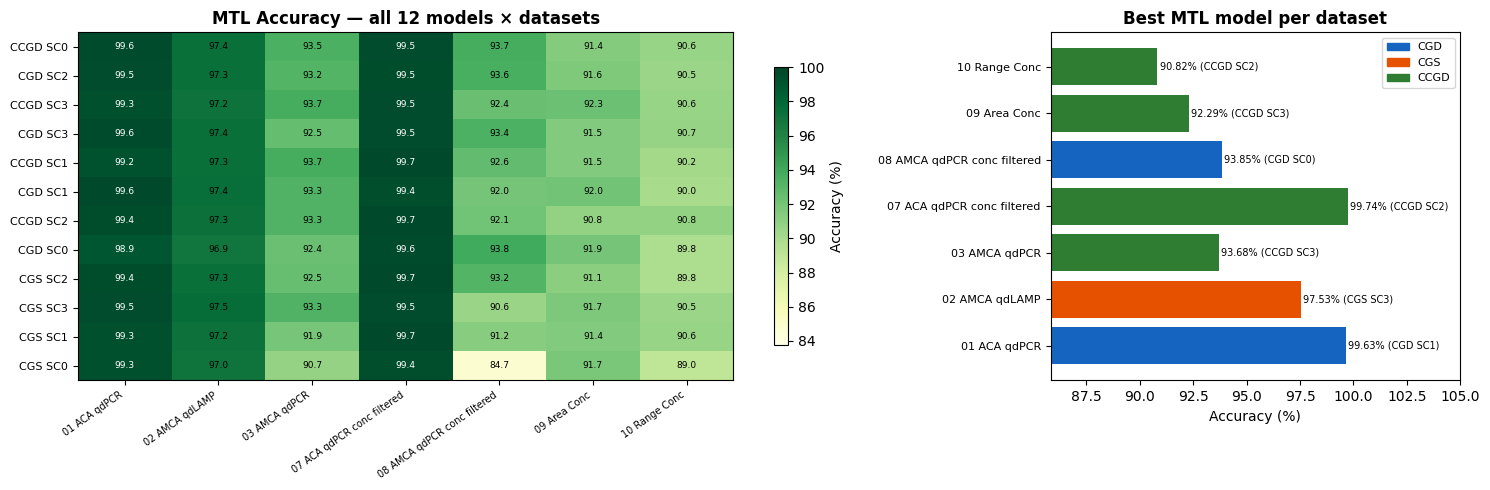


Best MTL accuracy configuration per dataset:
                    dataset    label arch  sc  acc_pct
               01_ACA_qdPCR  CGD SC1  CGD   1   99.629
             02_AMCA_qdLAMP  CGS SC3  CGS   3   97.527
              03_AMCA_qdPCR CCGD SC3 CCGD   3   93.685
 07_ACA_qdPCR_conc_filtered CCGD SC2 CCGD   2   99.736
08_AMCA_qdPCR_conc_filtered  CGD SC0  CGD   0   93.846
               09_Area_Conc CCGD SC3 CCGD   3   92.294
              10_Range_Conc CCGD SC2 CCGD   2   90.823

MTL mean acc by arch: {'CGD': 94.892, 'CGS': 94.255, 'CCGD': 94.946}
MTL mean acc by SC:   {0: 94.333, 1: 94.735, 2: 94.848, 3: 94.875}


In [14]:
mtl_df   = df[df['type'] == 'MTL'].copy()
mtl_ds   = [d for d in DS_ORDER if d in mtl_df['dataset'].cat.categories
            and not mtl_df[mtl_df['dataset']==d]['acc'].isna().all()]

pivot_mtl = (
    mtl_df.pivot_table(index='label', columns='dataset', values='acc', aggfunc='first') * 100
).reindex(columns=mtl_ds)
pivot_mtl = pivot_mtl.loc[pivot_mtl.mean(axis=1).sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2.0, 1]})

ax = axes[0]
im = ax.imshow(pivot_mtl.values, aspect='auto', cmap='YlGn',
               vmin=pivot_mtl.min().min()-1, vmax=100)
ax.set_xticks(range(len(pivot_mtl.columns)))
ax.set_xticklabels([c.replace('_', ' ') for c in pivot_mtl.columns],
                   rotation=35, ha='right', fontsize=7)
ax.set_yticks(range(len(pivot_mtl.index)))
ax.set_yticklabels(pivot_mtl.index, fontsize=8)
for i in range(pivot_mtl.shape[0]):
    for j in range(pivot_mtl.shape[1]):
        v = pivot_mtl.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=6.5,
                    color='black' if v < 98 else 'white')
plt.colorbar(im, ax=ax, shrink=0.8, label='Accuracy (%)')
ax.set_title('MTL Accuracy — all 12 models × datasets', fontweight='bold')

ax2 = axes[1]
best_mtl = mtl_df.loc[mtl_df.groupby('dataset', observed=True)['acc'].idxmax().dropna()].copy()
best_mtl = best_mtl.set_index('dataset').reindex(mtl_ds).dropna(subset=['acc']).reset_index()
colors   = [ARCH_COLORS[r] for r in best_mtl['arch']]
ax2.barh(range(len(best_mtl)), best_mtl['acc'] * 100, color=colors)
ax2.set_yticks(range(len(best_mtl)))
ax2.set_yticklabels([d.replace('_', ' ') for d in best_mtl['dataset']], fontsize=8)
for i, row in best_mtl.iterrows():
    ax2.text(row['acc']*100 + 0.1, i,
             f"{row['acc']*100:.2f}% ({row['label']})", va='center', fontsize=7)
ax2.set_xlim(left=best_mtl['acc'].min()*100 - 5, right=105)
ax2.set_xlabel('Accuracy (%)')
ax2.set_title('Best MTL model per dataset', fontweight='bold')
ax2.legend(handles=[mpatches.Patch(color=c, label=a) for a, c in ARCH_COLORS.items()],
           fontsize=8)
plt.tight_layout(); plt.show()

print('\nBest MTL accuracy configuration per dataset:')
print(best_mtl[['dataset','label','arch','sc','acc']]
      .assign(acc_pct=lambda x: (x.acc*100).round(3))
      .drop(columns='acc').to_string(index=False))
arch_mean_mtl = mtl_df.groupby('arch')['acc'].mean().reindex(['CGD','CGS','CCGD']) * 100
sc_mean_mtl   = mtl_df.groupby('sc')['acc'].mean() * 100
print('\nMTL mean acc by arch:', arch_mean_mtl.round(3).to_dict())
print('MTL mean acc by SC:  ', sc_mean_mtl.round(3).to_dict())

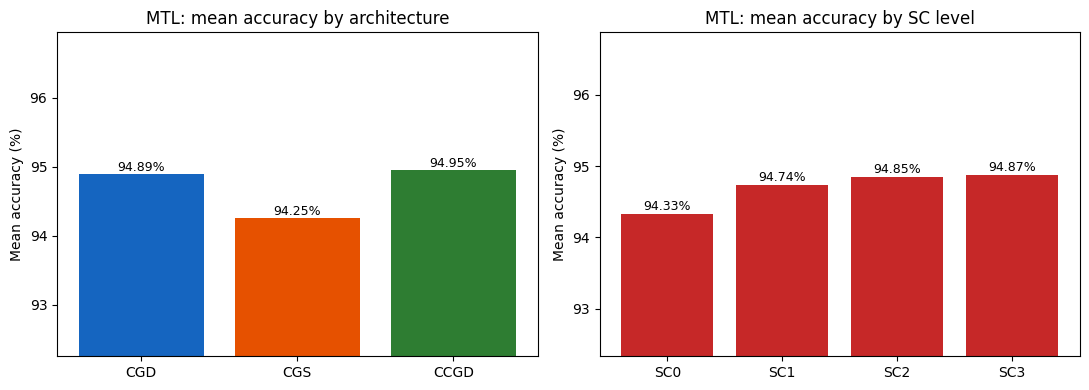

In [15]:
# Architecture & SC-level mean accuracy — MTL
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

arch_mean_mtl = mtl_df.groupby('arch')['acc'].mean().reindex(['CGD','CGS','CCGD']) * 100
axes[0].bar(arch_mean_mtl.index, arch_mean_mtl.values,
            color=[ARCH_COLORS[a] for a in arch_mean_mtl.index])
for i, v in enumerate(arch_mean_mtl.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)
axes[0].set_ylim(arch_mean_mtl.min()-2, arch_mean_mtl.max()+2)
axes[0].set_title('MTL: mean accuracy by architecture')
axes[0].set_ylabel('Mean accuracy (%)')

sc_mean_mtl = mtl_df.groupby('sc')['acc'].mean() * 100
axes[1].bar([f'SC{s}' for s in sc_mean_mtl.index], sc_mean_mtl.values, color='#C62828')
for i, v in enumerate(sc_mean_mtl.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)
axes[1].set_ylim(sc_mean_mtl.min()-2, sc_mean_mtl.max()+2)
axes[1].set_title('MTL: mean accuracy by SC level')
axes[1].set_ylabel('Mean accuracy (%)')

plt.tight_layout(); plt.show()

## 1c — Best MTL Model Configuration (RMSE)

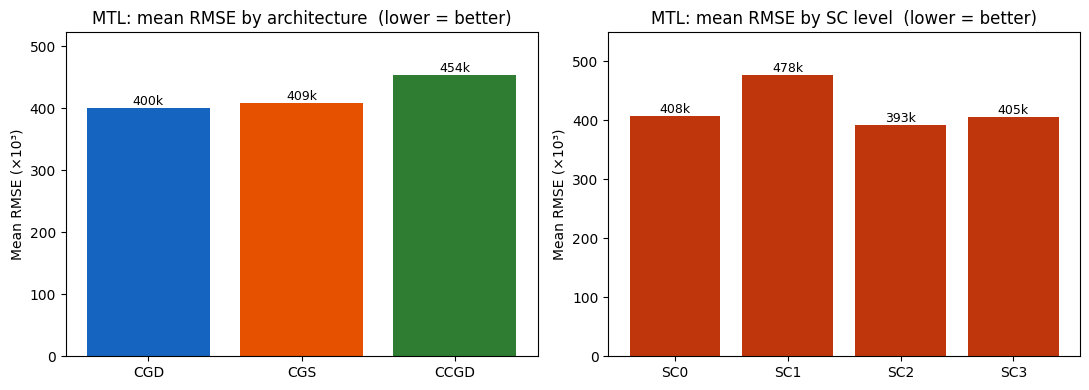

In [16]:
# Architecture & SC-level mean RMSE — MTL
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

arch_rmse = rmse_df.groupby('arch')['rmse'].mean().reindex(['CGD','CGS','CCGD']) / 1000
axes[0].bar(arch_rmse.index, arch_rmse.values,
            color=[ARCH_COLORS[a] for a in arch_rmse.index])
for i, v in enumerate(arch_rmse.values):
    axes[0].text(i, v + arch_rmse.max()*0.01, f'{v:.0f}k', ha='center', fontsize=9)
axes[0].set_ylim(0, arch_rmse.max() * 1.15)
axes[0].set_title('MTL: mean RMSE by architecture  (lower = better)')
axes[0].set_ylabel('Mean RMSE (×10³)')

sc_rmse = rmse_df.groupby('sc')['rmse'].mean() / 1000
axes[1].bar([f'SC{s}' for s in sc_rmse.index], sc_rmse.values, color='#BF360C')
for i, v in enumerate(sc_rmse.values):
    axes[1].text(i, v + sc_rmse.max()*0.01, f'{v:.0f}k', ha='center', fontsize=9)
axes[1].set_ylim(0, sc_rmse.max() * 1.15)
axes[1].set_title('MTL: mean RMSE by SC level  (lower = better)')
axes[1].set_ylabel('Mean RMSE (×10³)')

plt.tight_layout(); plt.show()

/tmp/ipykernel_183829/353034714.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rmse_df.pivot_table(index='label', columns='dataset', values='rmse', aggfunc='first') / 1000


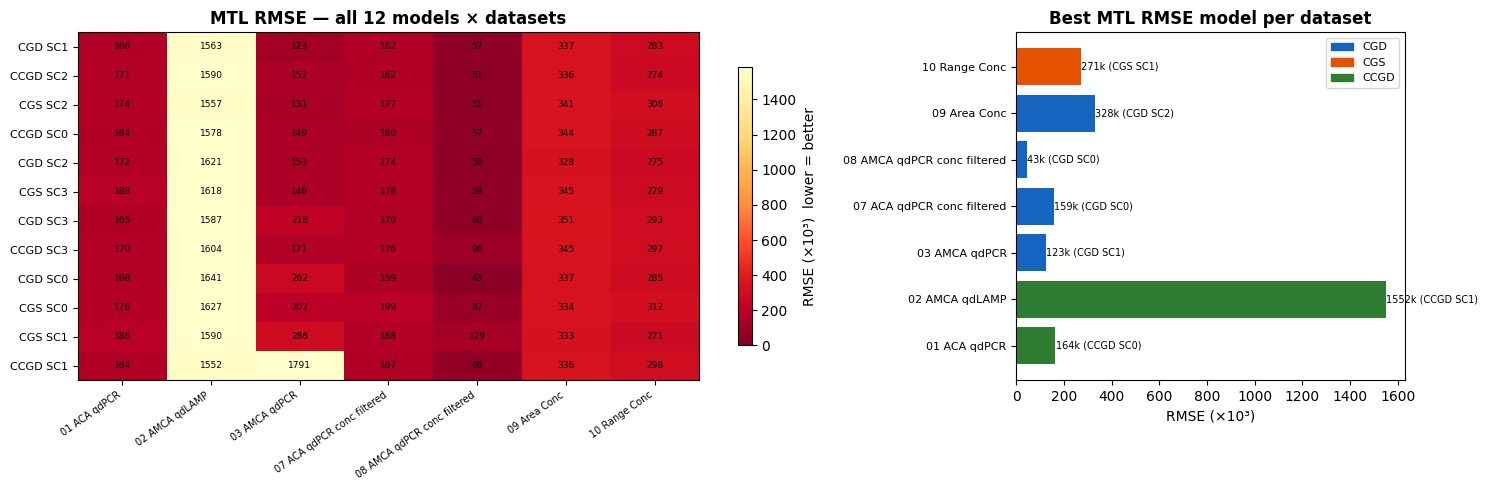


Best MTL RMSE configuration per dataset:
                    dataset    label arch  sc  rmse_k
               01_ACA_qdPCR CCGD SC0 CCGD   0   163.9
             02_AMCA_qdLAMP CCGD SC1 CCGD   1  1551.6
              03_AMCA_qdPCR  CGD SC1  CGD   1   122.9
 07_ACA_qdPCR_conc_filtered  CGD SC0  CGD   0   159.1
08_AMCA_qdPCR_conc_filtered  CGD SC0  CGD   0    42.6
               09_Area_Conc  CGD SC2  CGD   2   328.0
              10_Range_Conc  CGS SC1  CGS   1   270.6


In [17]:
rmse_df  = mtl_df[mtl_df['rmse'].notna()].copy()
rmse_ds  = [d for d in DS_ORDER if d in rmse_df['dataset'].values]

pivot_rmse = (
    rmse_df.pivot_table(index='label', columns='dataset', values='rmse', aggfunc='first') / 1000
).reindex(columns=rmse_ds)
pivot_rmse = pivot_rmse.loc[pivot_rmse.mean(axis=1).sort_values().index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2.0, 1]})

ax = axes[0]
vmax = float(np.nanpercentile(pivot_rmse.values, 90))
im   = ax.imshow(pivot_rmse.values, aspect='auto', cmap='YlOrRd_r', vmin=0, vmax=vmax)
ax.set_xticks(range(len(pivot_rmse.columns)))
ax.set_xticklabels([c.replace('_', ' ') for c in pivot_rmse.columns],
                   rotation=35, ha='right', fontsize=7)
ax.set_yticks(range(len(pivot_rmse.index)))
ax.set_yticklabels(pivot_rmse.index, fontsize=8)
for i in range(pivot_rmse.shape[0]):
    for j in range(pivot_rmse.shape[1]):
        v = pivot_rmse.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=6.5)
plt.colorbar(im, ax=ax, shrink=0.8, label='RMSE (×10³)  lower = better')
ax.set_title('MTL RMSE — all 12 models × datasets', fontweight='bold')

ax2 = axes[1]
best_rmse = rmse_df.loc[rmse_df.groupby('dataset', observed=True)['rmse'].idxmin().dropna()].copy()
best_rmse = best_rmse.set_index('dataset').reindex(rmse_ds).dropna(subset=['rmse']).reset_index()
colors    = [ARCH_COLORS[r] for r in best_rmse['arch']]
ax2.barh(range(len(best_rmse)), best_rmse['rmse'] / 1000, color=colors)
ax2.set_yticks(range(len(best_rmse)))
ax2.set_yticklabels([d.replace('_', ' ') for d in best_rmse['dataset']], fontsize=8)
for i, row in best_rmse.iterrows():
    ax2.text(row['rmse']/1000 + 0.5, i,
             f"{row['rmse']/1000:.0f}k ({row['label']})", va='center', fontsize=7)
ax2.set_xlabel('RMSE (×10³)')
ax2.set_title('Best MTL RMSE model per dataset', fontweight='bold')
ax2.legend(handles=[mpatches.Patch(color=c, label=a) for a, c in ARCH_COLORS.items()],
           fontsize=8)
plt.tight_layout(); plt.show()

print('\nBest MTL RMSE configuration per dataset:')
print(best_rmse[['dataset','label','arch','sc','rmse']]
      .assign(rmse_k=lambda x: (x.rmse/1000).round(1))
      .drop(columns='rmse').to_string(index=False))

## 2 — ST vs MTL Accuracy: Paired Comparison + Significance

In [18]:
# Best-of-12 per paradigm per dataset
best_st_acc  = st_df.groupby('dataset',  observed=True)['acc'].max() * 100
best_mtl_acc = mtl_df.groupby('dataset', observed=True)['acc'].max() * 100

# Inner join: keep only datasets where both paradigms have at least one non-NaN result
compare = pd.DataFrame({'ST': best_st_acc, 'MTL': best_mtl_acc}).dropna()
compare = compare.reindex([d for d in DS_ORDER if d in compare.index])
compare['Δ (MTL−ST)'] = compare['MTL'] - compare['ST']

print(f'Datasets in paired comparison: {len(compare)}  (task 14 excluded — ST only)\n')
print(compare.round(3))

st_vals  = compare['ST'].values
mtl_vals = compare['MTL'].values
diff     = compare['Δ (MTL−ST)'].values

t_stat, t_pval = stats.ttest_rel(mtl_vals, st_vals)
try:
    w_stat, w_pval = stats.wilcoxon(diff, alternative='two-sided')
except ValueError as e:
    w_stat, w_pval = np.nan, np.nan
    print('Wilcoxon skipped:', e)
cohens_d     = diff.mean() / diff.std(ddof=1)
n_mtl_better = (diff > 0).sum()
n_st_better  = (diff < 0).sum()

print(f'\nPaired t-test:        t={t_stat:.3f}, p={t_pval:.4f}')
print(f'Wilcoxon signed-rank: W={w_stat},    p={w_pval:.4f}')
print(f"Cohen's d:            {cohens_d:.3f}")
print(f'MTL > ST: {n_mtl_better}/{len(diff)} datasets  |  ST > MTL: {n_st_better}/{len(diff)}')
print(f'Mean Δ:   {diff.mean():.3f} pp  ±  {diff.std(ddof=1):.3f} pp')

Datasets in paired comparison: 7  (task 14 excluded — ST only)

                          ST     MTL  Δ (MTL−ST)
dataset                                         
01_ACA_qdPCR          99.567  99.629       0.062
02_AMCA_qdLAMP        97.582  97.527      -0.055
03_AMCA_qdPCR         94.146  93.685      -0.461
07_ACA_qdPCR_conc...  99.670  99.736       0.066
08_AMCA_qdPCR_con...  95.297  93.846      -1.450
09_Area_Conc          92.381  92.294      -0.087
10_Range_Conc         91.255  90.823      -0.433

Paired t-test:        t=-1.661, p=0.1478
Wilcoxon signed-rank: W=5.0,    p=0.1562
Cohen's d:            -0.628
MTL > ST: 2/7 datasets  |  ST > MTL: 5/7
Mean Δ:   -0.337 pp  ±  0.537 pp


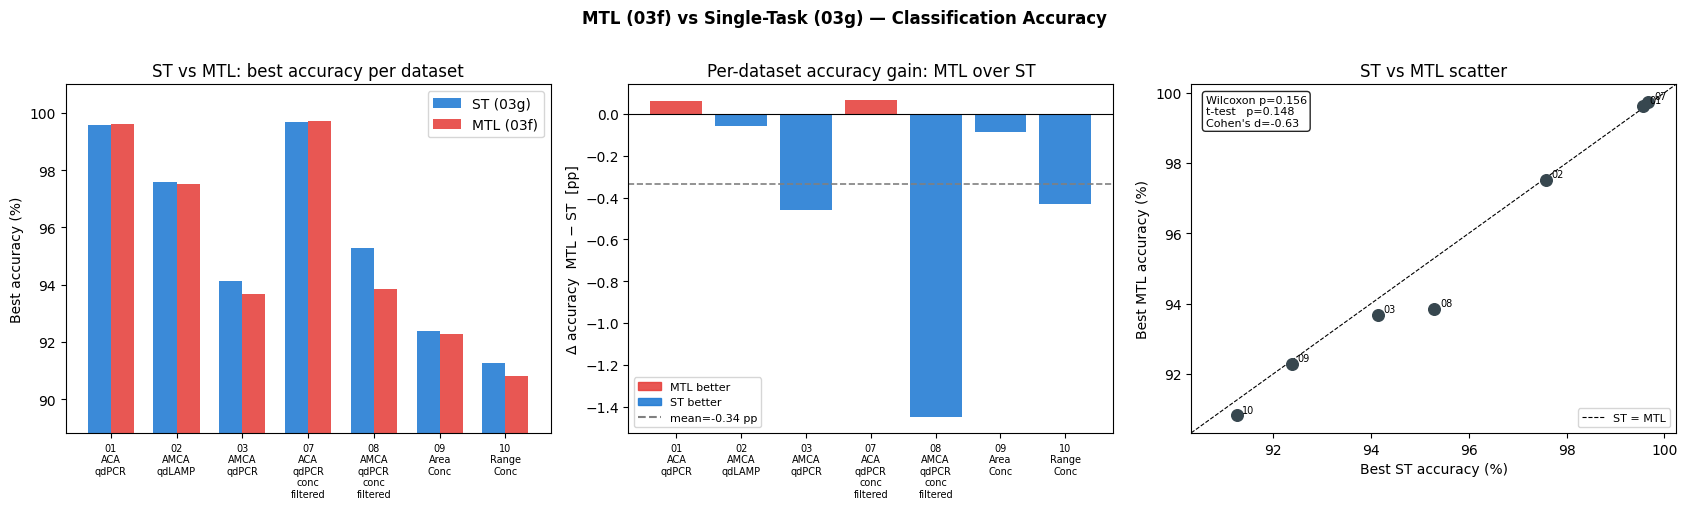

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

x, w = np.arange(len(compare)), 0.35

# ── Grouped bar ───────────────────────────────────────────────────────────
ax = axes[0]
ax.bar(x - w/2, compare['ST'],  w, label='ST (03g)',  color='#1976D2', alpha=0.85)
ax.bar(x + w/2, compare['MTL'], w, label='MTL (03f)', color='#E53935', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([d.replace('_', '\n') for d in compare.index], fontsize=7)
ax.set_ylabel('Best accuracy (%)')
ax.set_ylim(min(compare['ST'].min(), compare['MTL'].min()) - 2, 101)
ax.set_title('ST vs MTL: best accuracy per dataset')
ax.legend()

# ── Delta bar ─────────────────────────────────────────────────────────────
ax2 = axes[1]
delta_colors = ['#E53935' if d > 0 else '#1976D2' for d in diff]
ax2.bar(x, diff, color=delta_colors, alpha=0.85)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(diff.mean(), color='grey', lw=1.2, ls='--')
ax2.set_xticks(x)
ax2.set_xticklabels([d.replace('_', '\n') for d in compare.index], fontsize=7)
ax2.set_ylabel('Δ accuracy  MTL − ST  [pp]')
ax2.set_title('Per-dataset accuracy gain: MTL over ST')
ax2.legend(handles=[
    mpatches.Patch(color='#E53935', alpha=0.85, label='MTL better'),
    mpatches.Patch(color='#1976D2', alpha=0.85, label='ST better'),
    plt.Line2D([], [], color='grey', ls='--', label=f'mean={diff.mean():.2f} pp'),
], fontsize=8)

# ── Scatter + identity ────────────────────────────────────────────────────
ax3 = axes[2]
ax3.scatter(compare['ST'], compare['MTL'], s=70, color='#37474F', zorder=3)
for ds in compare.index:
    ax3.annotate(ds.split('_')[0],
                 (compare.loc[ds, 'ST'], compare.loc[ds, 'MTL']),
                 textcoords='offset points', xytext=(4, 2), fontsize=7)
lims = [
    min(compare['ST'].min(), compare['MTL'].min()) - 0.5,
    max(compare['ST'].max(), compare['MTL'].max()) + 0.5,
]
ax3.plot(lims, lims, 'k--', lw=0.8, label='ST = MTL')
ax3.set_xlabel('Best ST accuracy (%)'); ax3.set_ylabel('Best MTL accuracy (%)')
ax3.set_xlim(lims); ax3.set_ylim(lims)
ax3.set_title('ST vs MTL scatter')
w_pval_str = f'{w_pval:.3f}' if not np.isnan(w_pval) else 'n/a'
sig_str    = f'Wilcoxon p={w_pval_str}\nt-test   p={t_pval:.3f}\nCohen\'s d={cohens_d:.2f}'
ax3.text(0.03, 0.97, sig_str, transform=ax3.transAxes, va='top', fontsize=8,
         bbox=dict(boxstyle='round', fc='white', alpha=0.85))
ax3.legend(fontsize=8)

plt.suptitle('MTL (03f) vs Single-Task (03g) — Classification Accuracy',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# ── Final summary table ───────────────────────────────────────────────────
def best_label_for(sub_df, ds, col='acc', minimize=False):
    g = sub_df[sub_df['dataset'] == ds]
    if g[col].isna().all():
        return '-'
    idx = g[col].idxmin() if minimize else g[col].idxmax()
    return sub_df.loc[idx, 'label']

summary = compare.copy()
summary['best_ST_model']  = [best_label_for(st_df,   ds) for ds in compare.index]
summary['best_MTL_model'] = [best_label_for(mtl_df,  ds) for ds in compare.index]
summary['best_RMSE_model']= [best_label_for(rmse_df, ds, col='rmse', minimize=True)
                              for ds in compare.index]

pd.set_option('display.max_colwidth', 20)
print('── Final summary ──')
print(summary[['ST','MTL','Δ (MTL−ST)','best_ST_model','best_MTL_model','best_RMSE_model']].round(3))
print()
p_eff = min(t_pval, w_pval if not np.isnan(w_pval) else 1.0)
sig   = f'significant (p<0.05)' if p_eff < 0.05 else f'NOT significant (p={p_eff:.3f})'
print(f'MTL better in {n_mtl_better}/{len(diff)} datasets, ST better in {n_st_better}/{len(diff)}')
print(f"Significance: {sig} | mean Δ={diff.mean():.3f} pp | Cohen's d={cohens_d:.2f}")

── Final summary ──
                          ST     MTL  Δ (MTL−ST) best_ST_model best_MTL_model  \
dataset                                                                         
01_ACA_qdPCR          99.567  99.629       0.062      CCGD SC2        CGD SC1   
02_AMCA_qdLAMP        97.582  97.527      -0.055       CGD SC0        CGS SC3   
03_AMCA_qdPCR         94.146  93.685      -0.461       CGD SC0       CCGD SC3   
07_ACA_qdPCR_conc...  99.670  99.736       0.066       CGD SC1       CCGD SC2   
08_AMCA_qdPCR_con...  95.297  93.846      -1.450       CGD SC3        CGD SC0   
09_Area_Conc          92.381  92.294      -0.087       CGD SC0       CCGD SC3   
10_Range_Conc         91.255  90.823      -0.433      CCGD SC3       CCGD SC2   

                     best_RMSE_model  
dataset                               
01_ACA_qdPCR                CCGD SC0  
02_AMCA_qdLAMP              CCGD SC1  
03_AMCA_qdPCR                CGD SC1  
07_ACA_qdPCR_conc...         CGD SC0  
08_AMCA_qdPCR_co